In [2]:
# filepath: 
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)  # For reproducibility

In [3]:
class GaussianBandit:
    def __init__(self, mu, sigma=1.0):
        self.mu = mu
        self.sigma = sigma
        self.N = 0
        self.q_estimate = 0.0 
        self.sum_rewards = 0.0
    
    def pull(self):
        # Rewards are N(mu, 1)
        return np.random.normal(self.mu, self.sigma)
    
    def update(self, x):
        self.N += 1
        self.sum_rewards += x
        self.q_estimate += (x - self.q_estimate) / self.N

def plot_individual_runs(regret_data, param_values, param_name, algo_name):
    """
    Plots individual runs (gray) and the Pruned Average + 95% CI (red/shaded).
    """
    n_params = len(param_values)
    fig, axes = plt.subplots(1, n_params, figsize=(6 * n_params, 5), sharey=True)
    if n_params == 1: axes = [axes]
    
    final_avg_regrets = []
    
    for ax, param in zip(axes, param_values):
        # data shape: (n_experiments, n_steps)
        data = regret_data[param] 
        n_exp, n_steps = data.shape
        
        # 1. Plot individual runs (Gray background lines)
        # We plot a subset (e.g., first 20) to avoid clutter if n_exp is huge
        for i in range(min(n_exp, 50)): 
            ax.plot(data[i], color='gray', alpha=0.15, linewidth=0.8)
            
        # 2. Calculate Statistics (With Outlier Pruning)
        means = []
        cis = []
        
        # Iterate through each time step to process the "vertical slice" of data
        for t in range(n_steps):
            step_vals = data[:, t]
            
            # --- IQR PRUNING ---
            Q1 = np.percentile(step_vals, 25)
            Q3 = np.percentile(step_vals, 75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            
            # Filter
            clean_vals = step_vals[(step_vals >= lower) & (step_vals <= upper)]
            
            # If aggressive pruning empties data, fallback to raw
            if len(clean_vals) < 2:
                clean_vals = step_vals
            
            # --- MEAN & CI ---
            mean_val = np.mean(clean_vals)
            std_val = np.std(clean_vals)
            n_clean = len(clean_vals)
            
            # 95% Confidence Interval = 1.96 * Standard Error
            margin = 1.96 * (std_val / np.sqrt(n_clean))
            
            means.append(mean_val)
            cis.append(margin)
        
        means = np.array(means)
        cis = np.array(cis)
        steps = np.arange(n_steps)
        
        # 3. Plot Average and Confidence Interval
        ax.plot(steps, means, color='red', linewidth=2, label='Pruned Mean')
        ax.fill_between(steps, means - cis, means + cis, color='red', alpha=0.2, label='95% CI')
        
        # Save final value for the summary plot
        final_avg_regrets.append(means[-1])
        
        ax.set_title(f"{param_name} = {param}")
        ax.set_xlabel("Steps")
        ax.set_ylabel("Cumulative Regret")
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        
    plt.suptitle(f"{algo_name}: Individual Runs vs Average (Outliers Pruned)", y=1.02)
    plt.tight_layout()
    plt.show()
    
    # --- 4. SUMMARY PLOT ---
    plt.figure(figsize=(6, 4))
    plt.plot(param_values, final_avg_regrets, marker='o', linestyle='-', color='blue')
    plt.xlabel(param_name)
    plt.ylabel(f"Final Average Regret (T={n_steps})")
    plt.title(f"{algo_name}: Average Final Regret vs {param_name}")
    plt.grid(True)
    plt.show()

# Common settings
n_experiments = 500
n_steps = 1000
n_arms = 10

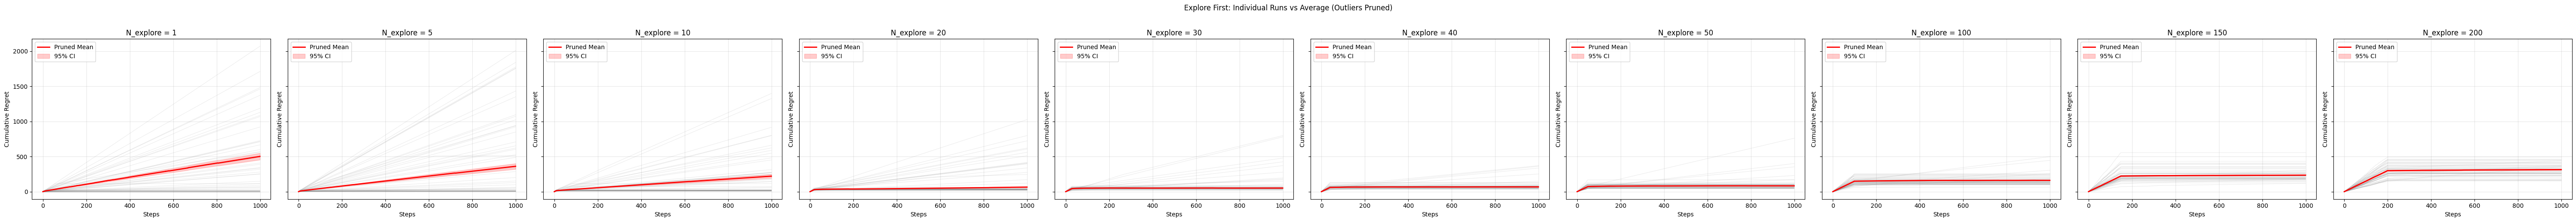

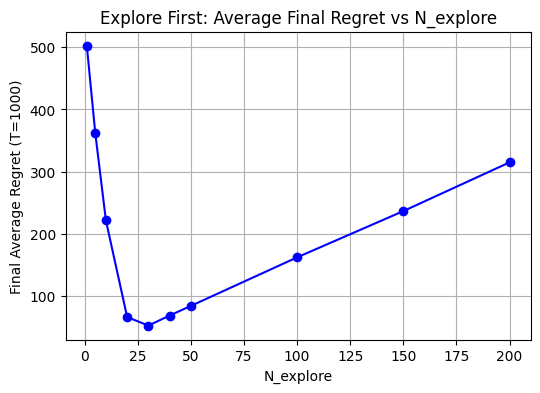

In [4]:
# filepath: 
# --- Explore First ---

def run_explore_first_sim(means, n_steps, explore):
    bandits = [GaussianBandit(mu) for mu in means]
    n_arms = len(bandits)
    optimal_mu = np.max(means)
    regrets = np.zeros(n_steps)
    
    step = 0
    # Exploration Phase
    for _ in range(explore):
        if step >= n_steps: break
        j = np.random.randint(n_arms)
        x = bandits[j].pull()
        bandits[j].update(x)
        regrets[step] = optimal_mu - bandits[j].mu
        step += 1
            
    # Exploitation Phase
    while step < n_steps:
        j = np.argmax([b.q_estimate for b in bandits])
        x = bandits[j].pull()
        bandits[j].update(x)
        regrets[step] = optimal_mu - bandits[j].mu
        step += 1
        
    return np.cumsum(regrets)

# Parameters to test (Number of pulls per arm)
explore_params = [1, 5, 10, 20, 30, 40, 50, 100, 150, 200] 
results_ef = {}

for p in explore_params:
    runs = np.zeros((n_experiments, n_steps))
    for i in range(n_experiments):
        means = np.random.normal(0, 1, n_arms) # New problem instance
        runs[i] = run_explore_first_sim(means, n_steps, explore=p)
    results_ef[p] = runs

plot_individual_runs(results_ef, explore_params, "N_explore", "Explore First")

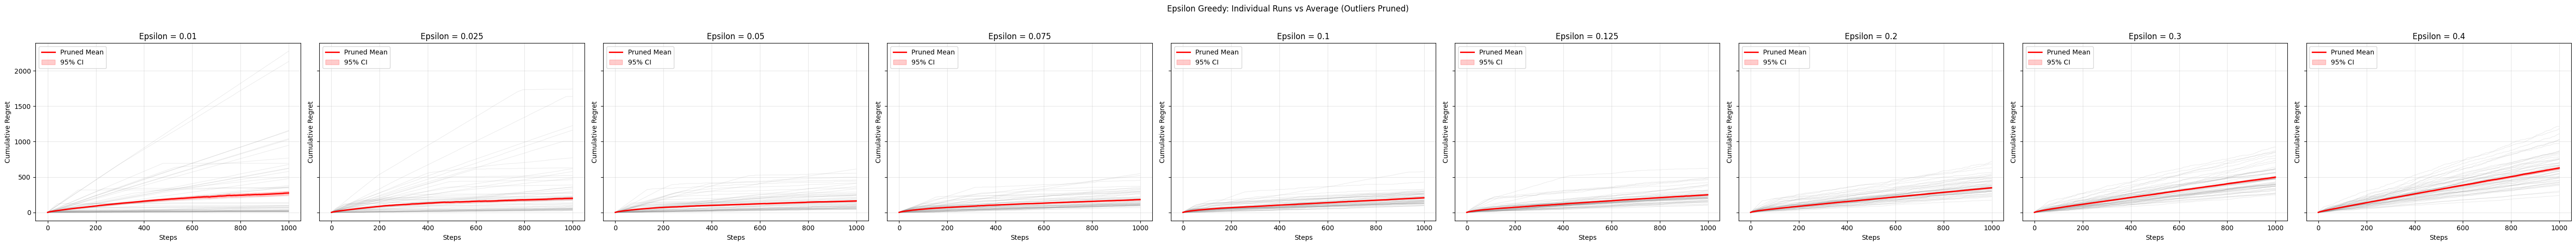

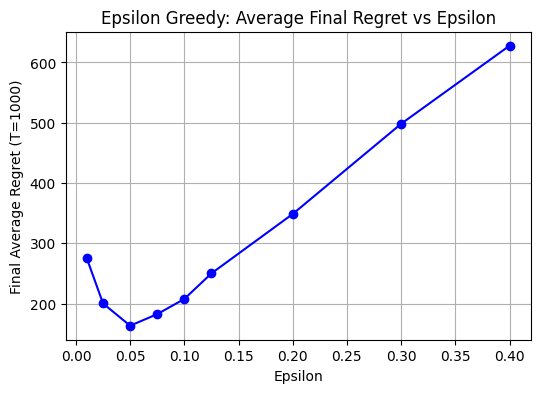

In [5]:
# filepath: 
# --- Epsilon Greedy ---

def run_epsilon_greedy_sim(means, n_steps, epsilon):
    bandits = [GaussianBandit(mu) for mu in means]
    n_arms = len(bandits)
    optimal_mu = np.max(means)
    regrets = np.zeros(n_steps)
    
    for step in range(n_steps):
        if np.random.random() < epsilon:
            j = np.random.randint(n_arms)
        else:
            j = np.argmax([b.q_estimate for b in bandits])
            
        x = bandits[j].pull()
        bandits[j].update(x)
        regrets[step] = optimal_mu - bandits[j].mu
        
    return np.cumsum(regrets)

# Parameters to test
eps_params = [0.01, 0.025, 0.05, 0.075, 0.1, 0.125, 0.2, 0.3, 0.4]
results_eg = {}

for eps in eps_params:
    runs = np.zeros((n_experiments, n_steps))
    for i in range(n_experiments):
        means = np.random.normal(0, 1, n_arms)
        runs[i] = run_epsilon_greedy_sim(means, n_steps, epsilon=eps)
    results_eg[eps] = runs

plot_individual_runs(results_eg, eps_params, "Epsilon", "Epsilon Greedy")

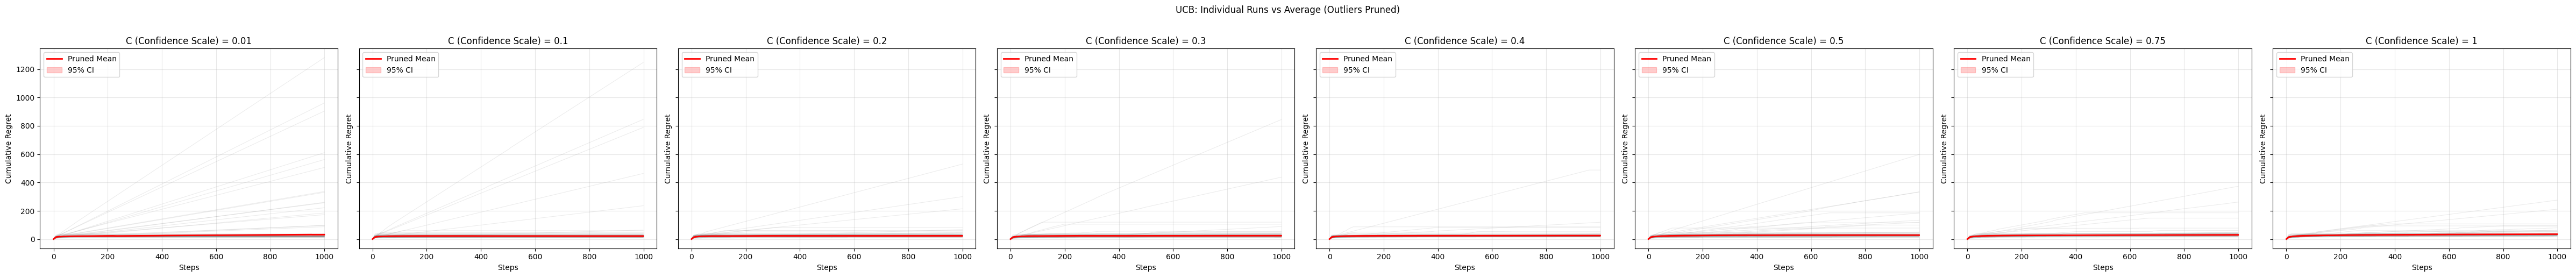

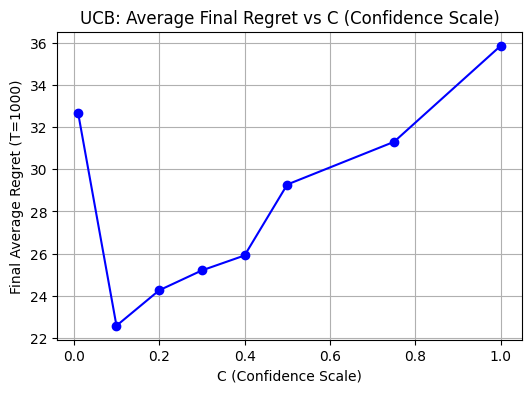

In [6]:
# filepath: 
# --- UCB ---

def run_ucb_sim(means, n_steps, c):
    bandits = [GaussianBandit(mu) for mu in means]
    n_arms = len(bandits)
    optimal_mu = np.max(means)
    regrets = np.zeros(n_steps)
    
    for step in range(n_steps):
        ucb_values = []
        for b in bandits:
            if b.N == 0:
                ucb_values.append(float('inf'))
            else:
                # UCB = Q(a) + c * sqrt(ln(t) / N(a))
                ucb_values.append(b.q_estimate +  np.sqrt(c * np.log(step + 1) / (2 * b.N)))
        
        j = np.argmax(ucb_values)
        x = bandits[j].pull()
        bandits[j].update(x)
        regrets[step] = optimal_mu - bandits[j].mu
        
    return np.cumsum(regrets)

# Parameters to test
c_params = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1]
results_ucb = {}

for c_val in c_params:
    runs = np.zeros((n_experiments, n_steps))
    for i in range(n_experiments):
        means = np.random.normal(0, 1, n_arms)
        runs[i] = run_ucb_sim(means, n_steps, c=c_val)
    results_ucb[c_val] = runs

plot_individual_runs(results_ucb, c_params, "C (Confidence Scale)", "UCB")

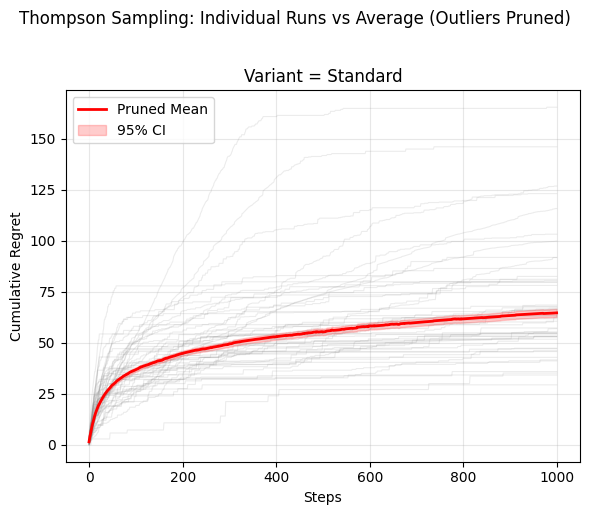

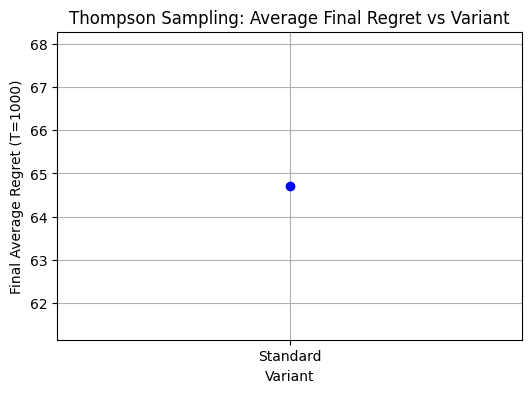

In [7]:
# filepath: 
# --- Thompson Sampling ---

def run_thompson_sim(means, n_steps):
    bandits = [GaussianBandit(mu) for mu in means]
    n_arms = len(bandits)
    optimal_mu = np.max(means)
    regrets = np.zeros(n_steps)
    
    for step in range(n_steps):
        samples = []
        for b in bandits:
            # Gaussian Posterior with known sigma=1 and N(0,1) prior
            precision_0 = 1.0 
            precision_data = 1.0 
            
            precision_n = precision_0 + b.N * precision_data
            sigma_sq_n = 1.0 / precision_n
            mu_n = sigma_sq_n * (0 + b.sum_rewards * precision_data)
            
            sample = np.random.normal(mu_n, np.sqrt(sigma_sq_n))
            samples.append(sample)
        
        j = np.argmax(samples)
        x = bandits[j].pull()
        bandits[j].update(x)
        regrets[step] = optimal_mu - bandits[j].mu
        
    return np.cumsum(regrets)

# TS usually doesn't have a hyperparameter to tune in this standard setting.
# We will just show 1 "parameter" case (Standard)
ts_params = ["Standard"]
results_ts = {}

runs = np.zeros((n_experiments, n_steps))
for i in range(n_experiments):
    means = np.random.normal(0, 1, n_arms)
    runs[i] = run_thompson_sim(means, n_steps)
results_ts["Standard"] = runs

plot_individual_runs(results_ts, ts_params, "Variant", "Thompson Sampling")

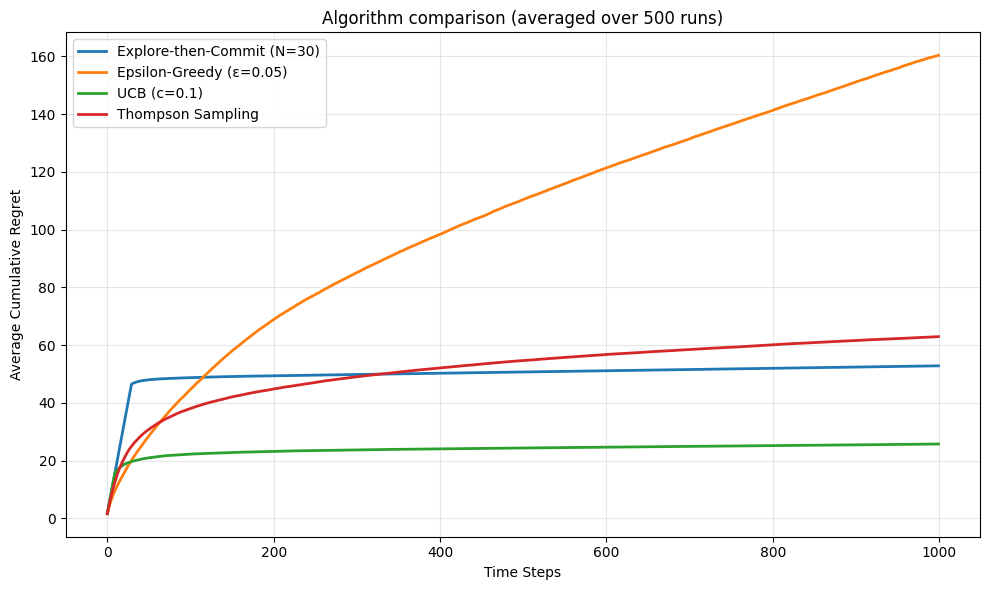

In [ ]:
# ...existing code...
# --- Final Comparison ---

opt_explore = 30
opt_epsilon = 0.05
opt_c = 0.1

avg_regret_ef = np.zeros((n_experiments, n_steps))
avg_regret_eg = np.zeros((n_experiments, n_steps))
avg_regret_ucb = np.zeros((n_experiments, n_steps))
avg_regret_ts = np.zeros((n_experiments, n_steps))

for _ in range(n_experiments):
    means = np.random.normal(0, 1, n_arms)

    avg_regret_ef[_] = run_explore_first_sim(means, n_steps, explore=opt_explore)
    avg_regret_eg[_] = run_epsilon_greedy_sim(means, n_steps, epsilon=opt_epsilon)
    avg_regret_ucb[_] = run_ucb_sim(means, n_steps, c=opt_c)
    avg_regret_ts[_] = run_thompson_sim(means, n_steps)

def prune_iqr(arr):
    """
    arr: shape (n_experiments, n_steps)
    returns: pruned arr with outlier runs removed
    """
    final_vals = arr[:, -1]  # final cumulative regret per run

    q1 = np.percentile(final_vals, 25)
    q3 = np.percentile(final_vals, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (final_vals >= lower) & (final_vals <= upper)
    return arr[mask]


# Apply pruning to all algorithms
avg_regret_ef = prune_iqr(avg_regret_ef)
avg_regret_eg = prune_iqr(avg_regret_eg)
avg_regret_ucb = prune_iqr(avg_regret_ucb)
avg_regret_ts = prune_iqr(avg_regret_ts)

# Recompute means after pruning
avg_regret_ef = avg_regret_ef.mean(axis=0)
avg_regret_eg = avg_regret_eg.mean(axis=0)
avg_regret_ucb = avg_regret_ucb.mean(axis=0)
avg_regret_ts = avg_regret_ts.mean(axis=0)



plt.figure(figsize=(10, 6))
plt.plot(avg_regret_ef, label=f'Explore-then-Commit (N={opt_explore})', linewidth=2)
plt.plot(avg_regret_eg, label=f'Epsilon-Greedy (ε={opt_epsilon})', linewidth=2)
plt.plot(avg_regret_ucb, label=f'UCB (c={opt_c})', linewidth=2)
plt.plot(avg_regret_ts, label='Thompson Sampling', linewidth=2)

plt.xlabel("Time Steps")
plt.ylabel("Average Cumulative Regret")
plt.title(f"Algorithm comparison (averaged over {n_experiments} runs)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q1

Converged in 139 iterations.


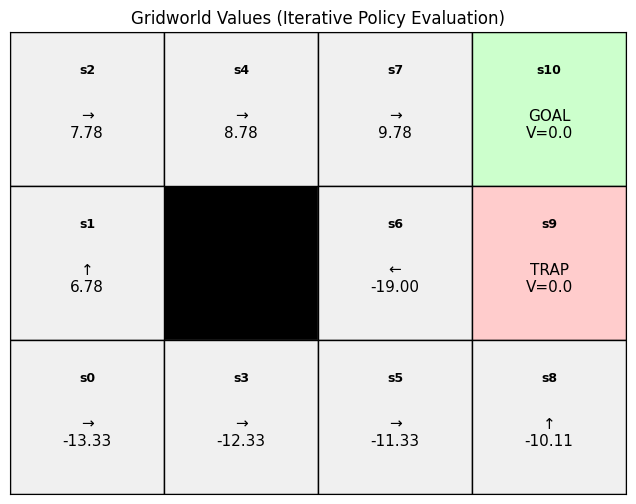

State Values from Iteration:
V(s0) = -13.3333
V(s1) = 6.7778
V(s2) = 7.7778
V(s3) = -12.3333
V(s4) = 8.7778
V(s5) = -11.3333
V(s6) = -19.0000
V(s7) = 9.7778
V(s8) = -10.1111
V(s9) = 0.0000
V(s10) = 0.0000


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def solve_iterative(gamma=1.0, theta=1e-6):
    # Initialize V(s) = 0 for all 11 states
    # States 0-8 are active. State 9 (Trap) and 12 (Goal) are terminal.
    V = np.zeros(11) 
    
    iteration = 0
    while True:
        delta = 0
        V_prev = V.copy()
        
        # Loop over all non-terminal states (0 to 8)
        # Note: We do NOT update s9 or s12 because V(terminal) must remain 0.
        for s in range(9):
            v = V[s]
            
            # --- Calculate Bellman Update based on the fixed policy ---
            
            # Reliable States (0-4)
            if s == 0:   # Right -> s3
                new_v = -1 + gamma * V_prev[3]
            elif s == 1: # Up -> s2
                new_v = -1 + gamma * V_prev[2]
            elif s == 2: # Right -> s4
                new_v = -1 + gamma * V_prev[4]
            elif s == 3: # Right -> s5
                new_v = -1 + gamma * V_prev[5]
            elif s == 4: # Right -> s7
                new_v = -1 + gamma * V_prev[7]
            
            # Unreliable States (5-8)
            elif s == 5: # Policy Right (0.9 -> s8, 0.1 -> s3)
                # Cost is always 1 for moving
                expected_next_val = 0.9 * V_prev[8] + 0.1 * V_prev[3]
                new_v = -1 + gamma * expected_next_val
                
            elif s == 6: # Policy Left (0.9 -> Wall/s6, 0.1 -> Trap/s9)
                # If 0.9 -> hit wall, stay in s6, cost 1
                # If 0.1 -> enter trap, cost 1, Trap Reward 10 = Total 11
                term1 = 0.9 * (-1 + gamma * V_prev[6])
                term2 = 0.1 * (-10 + gamma * V_prev[9]) # V_prev[9] is 0
                new_v = term1 + term2
                
            elif s == 7: # Policy Right (0.9 -> Goal/s12, 0.1 -> Left/s4)
                # If 0.9 -> enter goal, cost 1, Goal Reward +12 = Total +9
                # If 0.1 -> left to s4, cost 1
                term1 = 0.9 * (10 + gamma * V_prev[10]) # V_prev[12] is 0
                term2 = 0.1 * (-1 + gamma * V_prev[4])
                new_v = term1 + term2
                
            elif s == 8: # Policy Up (0.9 -> Trap/s9, 0.1 -> Wall/s8)
                # If 0.9 -> enter trap, cost 1, Trap Reward 10 = Total 11
                # If 0.1 -> hit wall, stay s8, cost 1
                term1 = 0.9 * (-10 + gamma * V_prev[9]) # V_prev[9] is 0
                term2 = 0.1 * (-1 + gamma * V_prev[8])
                new_v = term1 + term2

            # Update state value
            V[s] = new_v
            
            # Check convergence
            delta = max(delta, abs(v - new_v))
        
        iteration += 1
        if delta < theta:
            print(f"Converged in {iteration} iterations.")
            break
            
    return V

# --- Run Calculation ---
V_iterative = solve_iterative()

# --- Visualization (Same as before) ---
state_positions = {
    2: (0, 0), 4: (1, 0), 7: (2, 0), 10: (3, 0), 
    1: (0, 1), 6: (2, 1), 9: (3, 1),             
    0: (0, 2), 3: (1, 2), 5: (2, 2), 8: (3, 2)   
}
policy_labels = {
    0: "→", 1: "↑", 2: "→",
    3: "→", 4: "→", 5: "→",
    6: "←", 7: "→", 8: "↑",
    9: "TRAP", 10: "GOAL"
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

# Draw Grid
for row in range(3):
    for col in range(4):
        if row == 1 and col == 1:
            ax.add_patch(Rectangle((col-0.5, row-0.5), 1, 1, facecolor="black"))
        else:
            ax.add_patch(Rectangle((col-0.5, row-0.5), 1, 1, fill=False, edgecolor="gray"))

# Draw States and Values
for s, (col, row) in state_positions.items():
    val = V_iterative[s]
    if s == 9: color = "#ffcccc" 
    elif s == 10: color = "#ccffcc" 
    else: color = "#f0f0f0" 

    rect = Rectangle((col-0.5, row-0.5), 1, 1, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    
    if s in [9, 10]:
        label = f"{policy_labels[s]}\nV={val:.1f}"
    else:
        label = f"{policy_labels[s]}\n{val:.2f}"
        
    ax.text(col, row-0.25, f"s{s}", ha="center", va="center", fontsize=9, weight="bold")
    ax.text(col, row+0.1, label, ha="center", va="center", fontsize=11)

ax.set_title("Gridworld Values (Iterative Policy Evaluation)")
plt.gca().invert_yaxis()
plt.show()

# Print values to compare with Matrix method
print("State Values from Iteration:")
for i, v in enumerate(V_iterative):
    print(f"V(s{i}) = {v:.4f}")

Converged in 111 iterations.


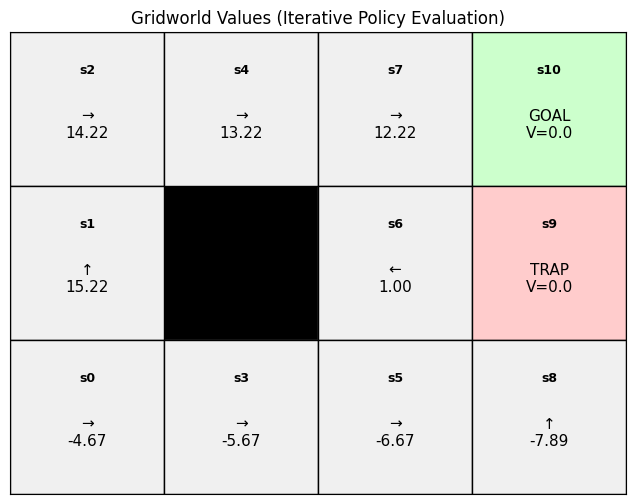

State Values from Iteration:
V(s0) = -4.6667
V(s1) = 15.2222
V(s2) = 14.2222
V(s3) = -5.6667
V(s4) = 13.2222
V(s5) = -6.6667
V(s6) = 1.0000
V(s7) = 12.2222
V(s8) = -7.8889
V(s9) = 0.0000
V(s10) = 0.0000


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def solve_iterative(gamma=1.0, theta=1e-6):
    # Initialize V(s) = 0 for all 11 states
    # States 0-8 are active. State 9 (Trap) and 12 (Goal) are terminal.
    V = np.zeros(11) 
    
    iteration = 0
    while True:
        delta = 0
        V_prev = V.copy()
        
        # Loop over all non-terminal states (0 to 8)
        # Note: We do NOT update s9 or s12 because V(terminal) must remain 0.
        for s in range(9):
            v = V[s]
            
            # --- Calculate Bellman Update based on the fixed policy ---
            
            # Reliable States (0-4)
            if s == 0:   # Right -> s3
                new_v = 1 + gamma * V_prev[3]
            elif s == 1: # Up -> s2
                new_v = 1 + gamma * V_prev[2]
            elif s == 2: # Right -> s4
                new_v = 1 + gamma * V_prev[4]
            elif s == 3: # Right -> s5
                new_v = 1 + gamma * V_prev[5]
            elif s == 4: # Right -> s7
                new_v = 1 + gamma * V_prev[7]
            
            # Unreliable States (5-8)
            elif s == 5: # Policy Right (0.9 -> s8, 0.1 -> s3)
                # Cost is always 1 for moving
                expected_next_val = 0.9 * V_prev[8] + 0.1 * V_prev[3]
                new_v = 1 + gamma * expected_next_val
                
            elif s == 6: # Policy Left (0.9 -> Wall/s6, 0.1 -> Trap/s9)
                # If 0.9 -> hit wall, stay in s6, cost 1
                # If 0.1 -> enter trap, cost 1, Trap Reward 10 = Total 11
                term1 = 0.9 * (1 + gamma * V_prev[6])
                term2 = 0.1 * (-8 + gamma * V_prev[9]) # V_prev[9] is 0
                new_v = term1 + term2
                
            elif s == 7: # Policy Right (0.9 -> Goal/s12, 0.1 -> Left/s4)
                # If 0.9 -> enter goal, cost 1, Goal Reward +12 = Total +9
                # If 0.1 -> left to s4, cost 1
                term1 = 0.9 * (12 + gamma * V_prev[10]) # V_prev[12] is 0
                term2 = 0.1 * (1 + gamma * V_prev[4])
                new_v = term1 + term2
                
            elif s == 8: # Policy Up (0.9 -> Trap/s9, 0.1 -> Wall/s8)
                # If 0.9 -> enter trap, cost 1, Trap Reward 10 = Total 11
                # If 0.1 -> hit wall, stay s8, cost 1
                term1 = 0.9 * (-8 + gamma * V_prev[9]) # V_prev[9] is 0
                term2 = 0.1 * (1 + gamma * V_prev[8])
                new_v = term1 + term2

            # Update state value
            V[s] = new_v
            
            # Check convergence
            delta = max(delta, abs(v - new_v))
        
        iteration += 1
        if delta < theta:
            print(f"Converged in {iteration} iterations.")
            break
            
    return V

# --- Run Calculation ---
V_iterative = solve_iterative()

# --- Visualization (Same as before) ---
state_positions = {
    2: (0, 0), 4: (1, 0), 7: (2, 0), 10: (3, 0), 
    1: (0, 1), 6: (2, 1), 9: (3, 1),             
    0: (0, 2), 3: (1, 2), 5: (2, 2), 8: (3, 2)   
}
policy_labels = {
    0: "→", 1: "↑", 2: "→",
    3: "→", 4: "→", 5: "→",
    6: "←", 7: "→", 8: "↑",
    9: "TRAP", 10: "GOAL"
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 2.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

# Draw Grid
for row in range(3):
    for col in range(4):
        if row == 1 and col == 1:
            ax.add_patch(Rectangle((col-0.5, row-0.5), 1, 1, facecolor="black"))
        else:
            ax.add_patch(Rectangle((col-0.5, row-0.5), 1, 1, fill=False, edgecolor="gray"))

# Draw States and Values
for s, (col, row) in state_positions.items():
    val = V_iterative[s]
    if s == 9: color = "#ffcccc" 
    elif s == 10: color = "#ccffcc" 
    else: color = "#f0f0f0" 

    rect = Rectangle((col-0.5, row-0.5), 1, 1, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    
    if s in [9, 10]:
        label = f"{policy_labels[s]}\nV={val:.1f}"
    else:
        label = f"{policy_labels[s]}\n{val:.2f}"
        
    ax.text(col, row-0.25, f"s{s}", ha="center", va="center", fontsize=9, weight="bold")
    ax.text(col, row+0.1, label, ha="center", va="center", fontsize=11)

ax.set_title("Gridworld Values (Iterative Policy Evaluation)")
plt.gca().invert_yaxis()
plt.show()

# Print values to compare with Matrix method
print("State Values from Iteration:")
for i, v in enumerate(V_iterative):
    print(f"V(s{i}) = {v:.4f}")